In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import warnings
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
warnings.filterwarnings('ignore')
from scipy import stats

# Custom font (optional)
font_path = "D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"
for f in font_manager.findSystemFonts(fontpaths=[font_path]):
    font_manager.fontManager.addfont(f)
plt.rcParams["font.family"] = "Inter"

In [2]:
specifiedpath = "D:\\"
filepath = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\OSAR_bothresponders_Full.xlsx"

df = pd.read_excel(filepath)


In [10]:
acr = df[df['responder'] == 'ACR'].set_index('MBON')
chrimson = df[df['responder'] == 'Chrimson2'].set_index('MBON')

mbons = acr.index.intersection(chrimson.index)
acr = acr.loc[mbons]
chrimson = chrimson.loc[mbons]

pref_acr = (acr['PI_Hg_OSAR'].abs() + acr['Light Attraction Index_Hg_OSAR'].abs()) / 2
pref_chr = (chrimson['PI_Hg_OSAR'].abs() + chrimson['Light Attraction Index_Hg_OSAR'].abs()) / 2

loco_acr = (acr['Log2 Bout Speed ratio_Hg_OSAR'].abs() + acr['Bout Number Index_Hg_OSAR'].abs() + acr['Bout Duration ratio_Hg_OSAR'].abs()) / 3
loco_chr = (chrimson['Log2 Bout Speed ratio_Hg_OSAR'].abs() + chrimson['Bout Number Index_Hg_OSAR'].abs() + chrimson['Bout Duration ratio_Hg_OSAR'].abs()) / 3

comb_acr = (pref_acr + loco_acr) / 2
comb_chr = (pref_chr + loco_chr) / 2

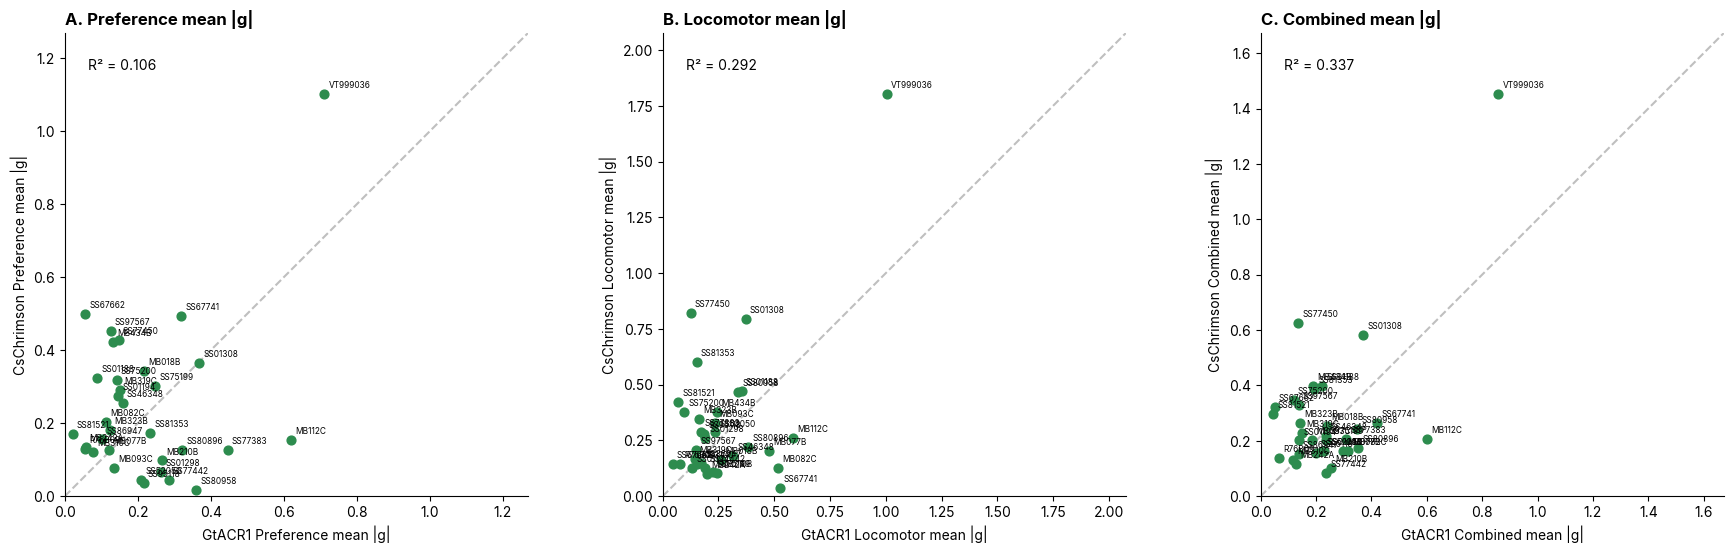

In [13]:
mpl.rcParams['svg.fonttype'] = 'none'

panels = [
    (pref_acr, pref_chr, 'Preference mean |g|'),
    (loco_acr, loco_chr, 'Locomotor mean |g|'),
    (comb_acr, comb_chr, 'Combined mean |g|'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (x, y, title), label in zip(axes, panels, ['A', 'B', 'C']):
    ax.scatter(x, y, s=40, color='#2D8C4E', zorder=3)

    for mbon in mbons:
        ax.annotate(mbon, (x[mbon], y[mbon]), fontsize=6, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points')

    lim = max(x.max(), y.max()) * 1.15
    ax.plot([0, lim], [0, lim], '--', color='gray', alpha=0.5, zorder=1)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)

    r_squared = stats.pearsonr(x, y)[0] ** 2
    ax.text(0.05, 0.92, f'R\u00b2 = {r_squared:.3f}', transform=ax.transAxes, fontsize=10)

    ax.set_xlabel(f'GtACR1 {title}', fontsize=10)
    ax.set_ylabel(f'CsChrimson {title}', fontsize=10)
    ax.set_title(f'{label}. {title}', fontsize=12, fontweight='bold', loc='left')
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()